In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest

project_path = '/content/drive/MyDrive/Spacecraft-Anomaly-Detection'

data_path = project_path + '/data/raw/archive/data/data'
train_path = data_path + '/train'
test_path = data_path + '/test'
labels_path = project_path + '/data/raw/archive/labeled_anomalies.csv'

print("SERIAL 16 loaded successfully.")
print("Project folder exists:", os.path.exists(project_path))
print("Train folder exists:", os.path.exists(train_path))
print("Test folder exists:", os.path.exists(test_path))
print("Labels file exists:", os.path.exists(labels_path))

Mounted at /content/drive
SERIAL 16 loaded successfully.
Project folder exists: True
Train folder exists: True
Test folder exists: True
Labels file exists: True


####load the training data and test data for A-8

Training data → used to learn what normal behavior looks like.

Test data → where we will search for anomalies.

In [2]:
channel = "A-8"

# Load training and test data
train_A8 = np.load(train_path + "/" + channel + ".npy")
test_A8 = np.load(test_path + "/" + channel + ".npy")

# Use the first column as the main telemetry signal
train_telemetry_A8 = train_A8[:, 0]
test_telemetry_A8 = test_A8[:, 0]

print("Channel:", channel)
print("Training data shape:", train_A8.shape)
print("Test data shape:", test_A8.shape)
print("Training telemetry shape:", train_telemetry_A8.shape)
print("Test telemetry shape:", test_telemetry_A8.shape)

Channel: A-8
Training data shape: (762, 25)
Test data shape: (8375, 25)
Training telemetry shape: (762,)
Test telemetry shape: (8375,)


Isolation Forest expects the input in 2D format:

[number_of_samples, number_of_features]

Our telemetry is currently:

(762,)

So we reshape it into:

(762, 1)

In [3]:
# Reshape telemetry into 2D format for the ML model
X_train_A8 = train_telemetry_A8.reshape(-1, 1)
X_test_A8 = test_telemetry_A8.reshape(-1, 1)

print("Training features shape:", X_train_A8.shape)
print("Test features shape:", X_test_A8.shape)

Training features shape: (762, 1)
Test features shape: (8375, 1)


In [4]:
# Create the Isolation Forest model
isolation_forest = IsolationForest(
    n_estimators=100,
    contamination="auto",
    random_state=42
)

# Train the model
isolation_forest.fit(X_train_A8)

print("Isolation Forest training completed.")

Isolation Forest training completed.


##Predict Anomalies

In [5]:
# Predict anomalies in the test data
isolation_predictions = isolation_forest.predict(X_test_A8)

# Convert Isolation Forest output:
# 1 = normal  → 0
# -1 = anomaly → 1
y_pred_isolation_A8 = (isolation_predictions == -1).astype(int)

print("Isolation Forest prediction completed.")
print("Predicted normal:", (y_pred_isolation_A8 == 0).sum())
print("Predicted anomalies:", (y_pred_isolation_A8 == 1).sum())

Isolation Forest prediction completed.
Predicted normal: 0
Predicted anomalies: 8375


Here All 8,375 test points were classified as anomalies.

It tells us something important: with contamination="auto" and a model trained only on A-8's training distribution, the test distribution is far enough from what the model learned that every test point falls on the anomaly side of its default decision threshold.

###Inspect Isolation Forest Scores

In [6]:
# Calculate anomaly scores for the test data
decision_scores_A8 = isolation_forest.decision_function(X_test_A8)

print("Decision scores calculated.")
print("Minimum score:", decision_scores_A8.min())
print("Maximum score:", decision_scores_A8.max())
print("Mean score:", decision_scores_A8.mean())
print("Number of scores below 0:", (decision_scores_A8 < 0).sum())

Decision scores calculated.
Minimum score: -0.16971329954471093
Maximum score: -0.03278147707345769
Mean score: -0.13992078364251187
Number of scores below 0: 8375


we known A-8 anomaly begins at index 4569.

We're looking for whether the score behavior changes around that point.

This will help us understand whether Isolation Forest is detecting something meaningful or simply seeing the entire test distribution as different from training.

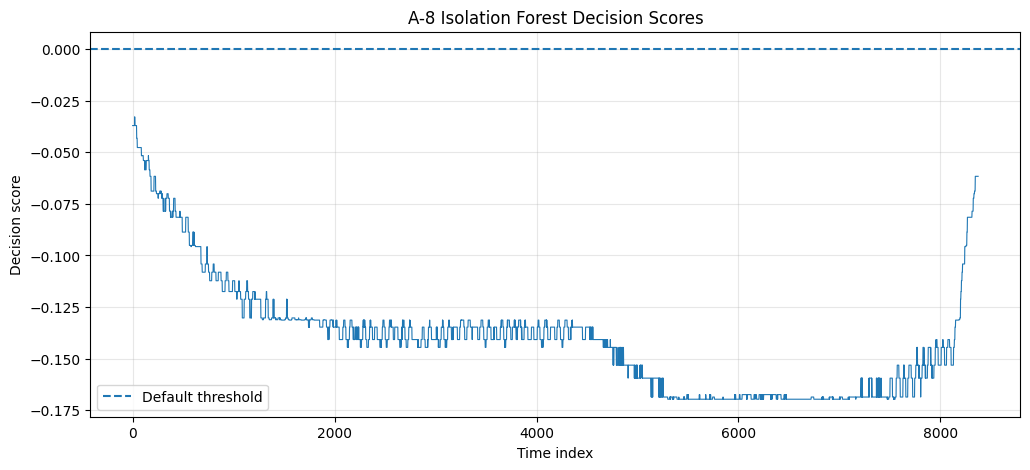

In [7]:
plt.figure(figsize=(12, 5))

plt.plot(decision_scores_A8, linewidth=0.8)

plt.axhline(0, linestyle="--", label="Default threshold")

plt.title("A-8 Isolation Forest Decision Scores")
plt.xlabel("Time index")
plt.ylabel("Decision score")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

##github commit


In [ ]:
%cd /content/drive/MyDrive/Spacecraft-Anomaly-Detection

!git status

/content/drive/MyDrive/Spacecraft-Anomaly-Detection
Refresh index: 100% (22/22), done.
